# Why Is Landsat Spatial Support Lower in 2020?

## Diagnostic notebook for the Yaoundé urban-expansion dataset

This notebook investigates one specific question:

> **Why is the final valid spatial support lower in 2020 than in 2015?**

It follows the data through the existing processing chain:

```text
Landsat catalogue
    → selected scenes
    → selected-scene footprint
    → pixels with at least one valid QA-masked observation
    → valid median composite
    → valid NDBI
    → final valid built-up state
```

The notebook is intentionally **diagnostic and read-only**. It does not:

- change the compositing windows;
- rebuild any Landsat composite;
- submit Earth Engine exports;
- overwrite any existing Earth Engine asset;
- modify the Version 1 dataset;
- select a new temporal window because an epoch looks anomalous.

It writes only reproducible tables, figures, and a short report to:

```text
reports/support_diagnostics/
```

## Interpretation of valid spatial support

In this analysis, **valid spatial support** means:

> The area within the Yaoundé administrative core where the final Landsat
> composite contains usable pixels after quality masking and where the
> selected built-up index can be calculated.

This support is independent of how much land is built-up. A cell may be:

```text
valid and built
valid and non-built
invalid
```

Ideally, support would be close to 100% for every epoch if the selected
scenes provided complete usable coverage. However, support is not expected
to increase monotonically through time because scene availability, scene
footprints, clouds, shadows, saturation, and sensor conditions vary between
acquisition windows.

## Expected project inputs

The notebook uses the files already created by the current pipeline:

```text
configs/landsat_catalog.yaml
configs/orchestrate_sources.yaml
configs/final_dataset.yaml

data/metadata/landsat/
├── scene_manifest_all.csv
├── selected_scene_manifest.csv
├── epoch_quality_summary.csv
└── compositing_protocol.yaml

data/metadata/built_up_candidates/
└── output_manifest.csv

data/metadata/final_dataset/
└── raster_output_manifest.csv

data/metadata/grid_specification.json
data/processed/boundaries/yaounde_core.gpkg
```

Core Python packages:

```text
pandas, numpy, matplotlib, pyyaml, geopandas
```

Earth Engine diagnostics require:

```text
earthengine-api
```

Authenticate in the active environment before running the Earth Engine
sections:

```bash
earthengine authenticate
```

In [4]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

try:
    import geopandas as gpd
except ImportError as error:
    raise ImportError(
        "geopandas is required to load the Yaoundé core boundary."
    ) from error

try:
    import ee
except ImportError:
    ee = None

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

In [5]:
def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from the current notebook location."""
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        required = [
            candidate / "configs/landsat_catalog.yaml",
            candidate / "configs/final_dataset.yaml",
        ]
        if all(path.is_file() for path in required):
            return candidate

    raise FileNotFoundError(
        "Could not locate the SprawlGP repository. "
        "Run this notebook from inside the repository."
    )


def read_yaml(path: Path) -> dict[str, Any]:
    """Read one YAML file and require a mapping at its root."""
    with path.open("r", encoding="utf-8") as stream:
        value = yaml.safe_load(stream)

    if not isinstance(value, dict):
        raise ValueError(f"Expected a YAML mapping in {path}.")

    return value


PROJECT_ROOT = find_project_root()
LANDSAT_CONFIG_PATH = PROJECT_ROOT / "configs/landsat_catalog.yaml"
ORCHESTRATION_CONFIG_PATH = (
    PROJECT_ROOT / "configs/orchestrate_sources.yaml"
)
FINAL_CONFIG_PATH = PROJECT_ROOT / "configs/final_dataset.yaml"

landsat_config = read_yaml(LANDSAT_CONFIG_PATH)
final_config = read_yaml(FINAL_CONFIG_PATH)
orchestration_config = (
    read_yaml(ORCHESTRATION_CONFIG_PATH)
    if ORCHESTRATION_CONFIG_PATH.is_file()
    else {}
)

REPORT_DIR = PROJECT_ROOT / "reports/support_diagnostics"
FIGURE_DIR = REPORT_DIR / "figures"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

PosixPath('/Users/omer/Documents/MIORPA/Pending.../SprawlGP')

In [6]:
PATHS = {
    "grid": PROJECT_ROOT / "data/metadata/grid_specification.json",
    "core_boundary": (
        PROJECT_ROOT
        / landsat_config["study_area"]["core_boundary"]
    ),
    "scene_manifest": (
        PROJECT_ROOT
        / landsat_config["outputs"]["directory"]
        / "scene_manifest_all.csv"
    ),
    "selected_scene_manifest": (
        PROJECT_ROOT
        / landsat_config["outputs"]["directory"]
        / "selected_scene_manifest.csv"
    ),
    "epoch_quality": (
        PROJECT_ROOT
        / landsat_config["outputs"]["directory"]
        / "epoch_quality_summary.csv"
    ),
    "compositing_protocol": (
        PROJECT_ROOT
        / landsat_config["outputs"]["directory"]
        / "compositing_protocol.yaml"
    ),
    "candidate_manifest": (
        PROJECT_ROOT
        / final_config["inputs"]["built_up_output_manifest"]
    ),
    "final_raster_manifest": (
        PROJECT_ROOT
        / final_config["metadata"]["directory"]
        / final_config["metadata"]["raster_output_manifest"]
    ),
}

missing_paths = [
    str(path.relative_to(PROJECT_ROOT))
    for path in PATHS.values()
    if not path.is_file()
]

if missing_paths:
    raise FileNotFoundError(
        "The diagnostic requires the following existing files:\n- "
        + "\n- ".join(missing_paths)
    )

with PATHS["grid"].open("r", encoding="utf-8") as stream:
    grid = json.load(stream)

scene_manifest = pd.read_csv(
    PATHS["scene_manifest"],
    parse_dates=["acquisition_date"],
)
selected_scenes = pd.read_csv(
    PATHS["selected_scene_manifest"],
    parse_dates=["acquisition_date"],
)
epoch_quality = pd.read_csv(PATHS["epoch_quality"])
candidate_manifest = pd.read_csv(
    PATHS["candidate_manifest"],
    keep_default_na=False,
)
final_raster_manifest = pd.read_csv(
    PATHS["final_raster_manifest"],
    keep_default_na=False,
)
protocol = read_yaml(PATHS["compositing_protocol"])

configured_epochs = [
    int(epoch)
    for epoch in final_config["mapping"]["epochs"]
]

print("Configured epochs:", configured_epochs)
print("All catalogue rows:", f"{len(scene_manifest):,}")
print("Selected scene rows:", f"{len(selected_scenes):,}")

Configured epochs: [2005, 2010, 2015, 2020, 2025]
All catalogue rows: 584
Selected scene rows: 25


## 1. Local preflight checks

These checks confirm that:

- all final epochs are represented in the selected-scene manifest;
- every selected scene exists in the full catalogue;
- the selected temporal protocol is available;
- exactly one candidate, count, index, and final-state asset can be
  identified for each epoch.

In [7]:
required_scene_columns = {
    "epoch",
    "sensor_key",
    "sensor_role",
    "earth_engine_asset_id",
    "acquisition_date",
    "cloud_cover_scene_pct",
    "valid_fraction_core",
    "has_positive_core_coverage",
    "candidate_for_composite",
}
missing_scene_columns = required_scene_columns.difference(
    scene_manifest.columns
)

if missing_scene_columns:
    raise ValueError(
        "scene_manifest_all.csv is missing columns: "
        f"{sorted(missing_scene_columns)}"
    )

required_selected_columns = {
    "epoch",
    "sensor_key",
    "earth_engine_asset_id",
    "acquisition_date",
    "selected_window_name",
    "selected_sensor_mode",
}
missing_selected_columns = required_selected_columns.difference(
    selected_scenes.columns
)

if missing_selected_columns:
    raise ValueError(
        "selected_scene_manifest.csv is missing columns: "
        f"{sorted(missing_selected_columns)}"
    )

selected_epochs = sorted(
    selected_scenes["epoch"].astype(int).unique().tolist()
)
missing_selected_epochs = sorted(
    set(configured_epochs).difference(selected_epochs)
)

selected_ids = set(
    selected_scenes["earth_engine_asset_id"].astype(str)
)
catalogue_ids = set(
    scene_manifest["earth_engine_asset_id"].astype(str)
)
unknown_selected_ids = sorted(
    selected_ids.difference(catalogue_ids)
)

preflight = pd.Series(
    {
        "configured_epochs": configured_epochs,
        "selected_epochs": selected_epochs,
        "missing_selected_epochs": missing_selected_epochs,
        "unknown_selected_scene_ids": len(unknown_selected_ids),
        "candidate_manifest_rows": len(candidate_manifest),
        "final_raster_manifest_rows": len(final_raster_manifest),
    },
    name="value",
)

if missing_selected_epochs:
    raise ValueError(
        "Selected-scene manifest does not contain all final epochs: "
        f"{missing_selected_epochs}"
    )

if unknown_selected_ids:
    raise ValueError(
        "Some selected scenes are absent from the full catalogue."
    )

preflight

configured_epochs             [2005, 2010, 2015, 2020, 2025]
selected_epochs               [2005, 2010, 2015, 2020, 2025]
missing_selected_epochs                                   []
unknown_selected_scene_ids                                 0
candidate_manifest_rows                                   10
final_raster_manifest_rows                                10
Name: value, dtype: object

## 2. Compositing protocol

The diagnostic keeps the existing objective decision rule unchanged. This
section reports the selected window, sensor mode, and dates without
proposing a replacement.

In [8]:
protocol_rows = []

for epoch in configured_epochs:
    raw_epoch = protocol.get("epochs", {}).get(epoch)

    if raw_epoch is None:
        raw_epoch = protocol.get("epochs", {}).get(str(epoch))

    if raw_epoch is None:
        raise KeyError(
            f"Epoch {epoch} is missing from compositing_protocol.yaml."
        )

    protocol_rows.append(
        {
            "epoch": epoch,
            "window_name": raw_epoch["window_name"],
            "window_start": raw_epoch["window_start"],
            "window_end": raw_epoch["window_end"],
            "sensor_mode": raw_epoch["sensor_mode"],
            "sensors": ",".join(raw_epoch["sensor_keys"]),
            "protocol_scene_count": int(
                raw_epoch["scene_count"]
            ),
        }
    )

protocol_table = pd.DataFrame(protocol_rows)
protocol_table

,epoch,window_name,window_start,window_end,sensor_mode,sensors,protocol_scene_count
0,2005,Jul-Sep_3m,2005-07-01,2005-10-01,primary_plus_supplemental,"LT05,LE07",2
1,2010,Jul-Sep_3m,2010-07-01,2010-10-01,primary_plus_supplemental,"LT05,LE07",1
2,2015,Jul-Sep_3m,2015-07-01,2015-10-01,primary_only,LC08,2
3,2020,Jul-Sep_3m,2020-07-01,2020-10-01,primary_only,LC08,1
4,2025,Nov-Jan_3m,2024-11-01,2025-02-01,primary_only,"LC08,LC09",19


## 3. Scene inventory

Three scene counts are kept separate:

- **catalogue scene count**: all scenes queried for the epoch, including
  diagnostic-only sensors;
- **candidate scene count**: catalogue scenes marked as candidates for
  compositing;
- **selected scene count**: the exact frozen scenes used to build the
  composite.

This distinction helps determine whether 2020 has fewer available scenes,
fewer eligible scenes, or fewer selected scenes than 2015.

In [9]:
def as_boolean(series: pd.Series) -> pd.Series:
    """Convert common CSV boolean representations safely."""
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)

    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
    )
    return normalized.isin({"true", "1", "yes"})


scene_manifest = scene_manifest.copy()
scene_manifest["candidate_for_composite_bool"] = as_boolean(
    scene_manifest["candidate_for_composite"]
)
scene_manifest["positive_core_coverage_bool"] = as_boolean(
    scene_manifest["has_positive_core_coverage"]
)

inventory_rows = []

for epoch in configured_epochs:
    all_epoch = scene_manifest[
        scene_manifest["epoch"].astype(int) == epoch
    ].copy()
    candidates = all_epoch[
        all_epoch["candidate_for_composite_bool"]
    ].copy()
    selected = selected_scenes[
        selected_scenes["epoch"].astype(int) == epoch
    ].copy()

    inventory_rows.append(
        {
            "epoch": epoch,
            "catalogue_scene_count": int(len(all_epoch)),
            "candidate_scene_count": int(len(candidates)),
            "selected_scene_count": int(len(selected)),
            "selected_sensors": ",".join(
                sorted(
                    selected["sensor_key"]
                    .astype(str)
                    .unique()
                    .tolist()
                )
            ),
            "first_selected_date": (
                selected["acquisition_date"].min().date().isoformat()
                if not selected.empty
                else None
            ),
            "last_selected_date": (
                selected["acquisition_date"].max().date().isoformat()
                if not selected.empty
                else None
            ),
            "median_selected_scene_cloud_cover_pct": (
                float(
                    pd.to_numeric(
                        selected["cloud_cover_scene_pct"],
                        errors="coerce",
                    ).median()
                )
                if not selected.empty
                else np.nan
            ),
            "median_selected_scene_valid_fraction_core": (
                float(
                    pd.to_numeric(
                        selected["valid_fraction_core"],
                        errors="coerce",
                    ).median()
                )
                if not selected.empty
                else np.nan
            ),
        }
    )

scene_inventory = (
    pd.DataFrame(inventory_rows)
    .merge(protocol_table, on="epoch", how="left")
    .sort_values("epoch")
    .reset_index(drop=True)
)

scene_inventory

,epoch,catalogue_scene_count,candidate_scene_count,selected_scene_count,selected_sensors,first_selected_date,last_selected_date,median_selected_scene_cloud_cover_pct,median_selected_scene_valid_fraction_core,window_name,window_start,window_end,sensor_mode,sensors,protocol_scene_count
0,2005,41,27,2,LE07,2005-07-19,2005-08-20,75.000,0.032624,Jul-Sep_3m,2005-07-01,2005-10-01,primary_plus_supplemental,"LT05,LE07",2
1,2010,52,35,1,LE07,2010-09-19,2010-09-19,62.000,0.270345,Jul-Sep_3m,2010-07-01,2010-10-01,primary_plus_supplemental,"LT05,LE07",1
2,2015,161,116,2,LC08,2015-07-07,2015-07-07,56.285,0.428494,Jul-Sep_3m,2015-07-01,2015-10-01,primary_only,LC08,2
3,2020,162,64,1,LC08,2020-08-05,2020-08-05,69.100,0.311741,Jul-Sep_3m,2020-07-01,2020-10-01,primary_only,LC08,1
4,2025,127,91,19,"LC08,LC09",2024-11-04,2025-01-31,37.900,0.371503,Nov-Jan_3m,2024-11-01,2025-02-01,primary_only,"LC08,LC09",19


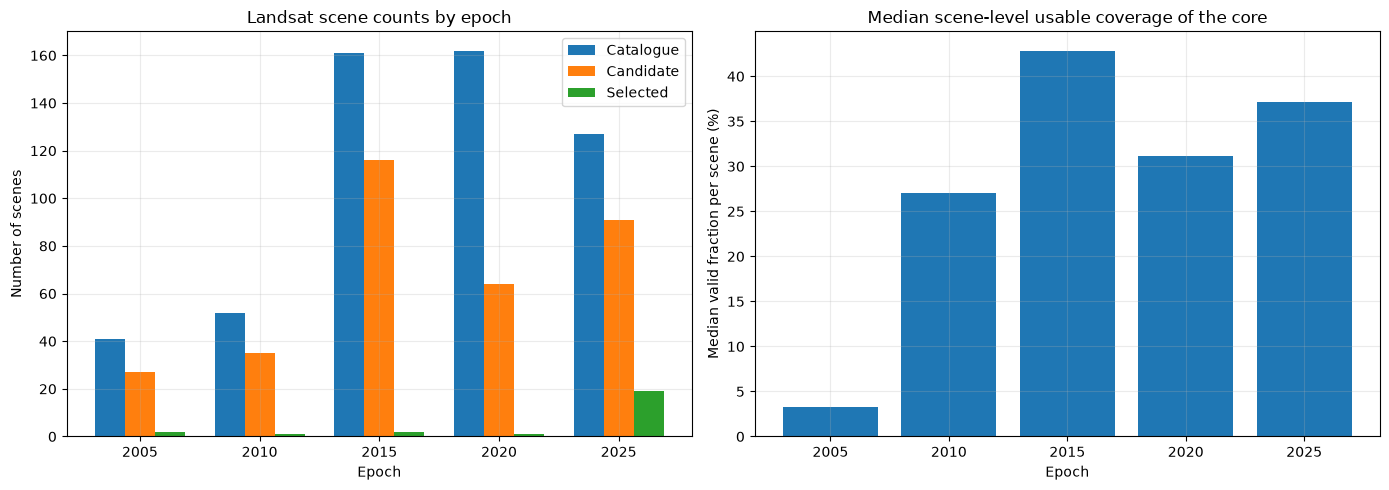

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(scene_inventory))
width = 0.25

axes[0].bar(
    x - width,
    scene_inventory["catalogue_scene_count"],
    width,
    label="Catalogue",
)
axes[0].bar(
    x,
    scene_inventory["candidate_scene_count"],
    width,
    label="Candidate",
)
axes[0].bar(
    x + width,
    scene_inventory["selected_scene_count"],
    width,
    label="Selected",
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(scene_inventory["epoch"])
axes[0].set_title("Landsat scene counts by epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Number of scenes")
axes[0].legend()

axes[1].bar(
    scene_inventory["epoch"].astype(str),
    (
        scene_inventory[
            "median_selected_scene_valid_fraction_core"
        ]
        * 100
    ),
)
axes[1].set_title(
    "Median scene-level usable coverage of the core"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Median valid fraction per scene (%)")

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "01_scene_inventory.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## 4. Resolve the existing Earth Engine assets

The asset identifiers are read from the existing manifests rather than
reconstructed from naming conventions.

For each epoch, the notebook resolves:

- source Landsat composite;
- valid-observation-count image;
- continuous-index image containing `valid_composite`;
- candidate image containing `valid_ndbi`;
- final state image containing `built_state_valid`.

In [11]:
def one_manifest_row(
    frame: pd.DataFrame,
    *,
    product_type: str,
    epoch: int,
) -> pd.Series:
    """Return exactly one passing manifest row."""
    subset = frame[
        (
            frame["product_type"].astype(str)
            == product_type
        )
        & (
            pd.to_numeric(
                frame["epoch"],
                errors="coerce",
            )
            == epoch
        )
    ].copy()

    if "state" in subset.columns:
        subset = subset[
            subset["state"]
            .astype(str)
            .str.upper()
            .isin({"PASS", "COMPLETED", "SUCCEEDED"})
        ]

    if len(subset) != 1:
        raise ValueError(
            f"Expected one {product_type} row for {epoch}; "
            f"found {len(subset)}."
        )

    return subset.iloc[0]


asset_rows = []

for epoch in configured_epochs:
    candidate_row = one_manifest_row(
        candidate_manifest,
        product_type="candidates",
        epoch=epoch,
    )
    index_row = one_manifest_row(
        candidate_manifest,
        product_type="indices",
        epoch=epoch,
    )
    state_row = one_manifest_row(
        final_raster_manifest,
        product_type="state",
        epoch=epoch,
    )

    asset_rows.append(
        {
            "epoch": epoch,
            "composite_asset": str(
                candidate_row["source_composite_asset"]
            ),
            "count_asset": str(
                candidate_row["source_count_asset"]
            ),
            "index_asset": str(index_row["asset_id"]),
            "candidate_asset": str(
                candidate_row["asset_id"]
            ),
            "state_asset": str(state_row["asset_id"]),
        }
    )

assets = pd.DataFrame(asset_rows)
assets

,epoch,composite_asset,count_asset,index_asset,candidate_asset,state_asset
0,2005,projects/urban-sprawl-ssa/assets/sprawlgp/v1/l...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/l...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/i...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/b...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/f...
1,2010,projects/urban-sprawl-ssa/assets/sprawlgp/v1/l...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/l...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/i...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/b...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/f...
2,2015,projects/urban-sprawl-ssa/assets/sprawlgp/v1/l...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/l...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/i...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/b...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/f...
3,2020,projects/urban-sprawl-ssa/assets/sprawlgp/v1/l...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/l...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/i...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/b...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/f...
4,2025,projects/urban-sprawl-ssa/assets/sprawlgp/v1/l...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/l...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/i...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/b...,projects/urban-sprawl-ssa/assets/sprawlgp/v1/f...


## 5. Earth Engine initialization

This is the only external service used by the notebook. All operations are
reductions or visual previews. No batch export task is created.

In [12]:
if ee is None:
    raise ImportError(
        "earthengine-api is not installed in this environment."
    )

try:
    ee.Initialize(
        project=final_config["project"]["earth_engine_project"]
    )
    print("Earth Engine initialized successfully.")
except Exception as error:
    raise RuntimeError(
        "Earth Engine initialization failed. "
        "Run `earthengine authenticate` and restart the kernel."
    ) from error

Earth Engine initialized successfully.


In [13]:
core_gdf = gpd.read_file(PATHS["core_boundary"])

if core_gdf.empty:
    raise ValueError("The Yaoundé core boundary is empty.")

core_gdf = core_gdf.to_crs("EPSG:4326")
core_geometry_mapping = core_gdf.geometry.unary_union.__geo_interface__
core_geometry = ee.Geometry(core_geometry_mapping)

core_area_m2 = float(
    gpd.read_file(PATHS["core_boundary"])
    .to_crs(grid["crs"])
    .geometry
    .area
    .sum()
)
core_area_ha = core_area_m2 / 10_000

print(f"Administrative core area: {core_area_ha:,.2f} ha")

Administrative core area: 28,972.90 ha


/var/folders/gv/71l1ft2j16519jw9fxm_939h0000gn/T/ipykernel_84919/1334076123.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  core_geometry_mapping = core_gdf.geometry.unary_union.__geo_interface__


## 6. Earth Engine helper functions

Every stage uses:

- the same administrative-core geometry;
- the same frozen CRS and affine transform;
- the same area reducer;
- the same denominator.

Small boundary differences may arise from raster-vector intersection, but
these cannot explain large changes such as approximately 60% versus 31%.

In [14]:
REDUCTION_ARGUMENTS = {
    "geometry": core_geometry,
    "crs": grid["crs"],
    "crsTransform": grid["transform"],
    "maxPixels": int(
        orchestration_config
        .get("exports", {})
        .get("max_pixels", 10_000_000)
    ),
    "tileScale": 4,
}


def safe_dictionary_number(
    dictionary: ee.Dictionary,
    key: str,
) -> ee.Number:
    """Read one reducer result and replace a missing key with zero."""
    return ee.Number(
        ee.Algorithms.If(
            dictionary.contains(key),
            dictionary.get(key),
            0,
        )
    )


def mask_area_m2(mask: ee.Image) -> float:
    """Calculate masked area inside the administrative core."""
    area_image = (
        ee.Image.pixelArea()
        .updateMask(ee.Image(mask).gt(0))
        .rename("area")
    )
    result = ee.Dictionary(
        area_image.reduceRegion(
            reducer=ee.Reducer.sum(),
            **REDUCTION_ARGUMENTS,
        )
    )
    return float(
        safe_dictionary_number(result, "area").getInfo()
    )


def mask_coverage(mask: ee.Image) -> dict[str, float]:
    """Return area and percentage for one binary support mask."""
    area_m2 = mask_area_m2(mask)
    return {
        "area_ha": area_m2 / 10_000,
        "pct_of_core": area_m2 / core_area_m2 * 100,
    }


def selected_scene_footprint(
    scene_ids: Iterable[str],
) -> ee.Image:
    """Create the union footprint of the selected scenes."""
    footprint_images = [
        ee.Image.constant(1)
        .clip(ee.Image(scene_id).geometry())
        .rename("footprint")
        for scene_id in scene_ids
    ]

    if not footprint_images:
        return ee.Image.constant(0).rename("footprint")

    return (
        ee.ImageCollection.fromImages(footprint_images)
        .max()
        .unmask(0)
        .rename("footprint")
    )


def count_statistics(
    count_image: ee.Image,
) -> dict[str, float]:
    """Summarize valid-observation depth across the core."""
    count = (
        ee.Image(count_image)
        .select("valid_observation_count")
        .unmask(0)
        .toFloat()
    )
    covered = count.updateMask(count.gt(0))

    all_core_result = ee.Dictionary(
        count.reduceRegion(
            reducer=(
                ee.Reducer.mean()
                .combine(
                    ee.Reducer.percentile(
                        [0, 25, 50, 75, 90, 100]
                    ),
                    sharedInputs=True,
                )
            ),
            **REDUCTION_ARGUMENTS,
        )
    ).getInfo()

    covered_result = ee.Dictionary(
        covered.reduceRegion(
            reducer=(
                ee.Reducer.mean()
                .combine(
                    ee.Reducer.percentile(
                        [25, 50, 75]
                    ),
                    sharedInputs=True,
                )
            ),
            **REDUCTION_ARGUMENTS,
        )
    ).getInfo()

    histogram_raw = ee.Dictionary(
        count.reduceRegion(
            reducer=ee.Reducer.frequencyHistogram(),
            **REDUCTION_ARGUMENTS,
        )
    ).getInfo()
    histogram = histogram_raw.get(
        "valid_observation_count",
        {},
    )

    def read(
        mapping: dict[str, Any],
        key: str,
    ) -> float:
        value = mapping.get(key)
        return float(value) if value is not None else np.nan

    return {
        "mean_valid_observations_all_core": read(
            all_core_result,
            "valid_observation_count_mean",
        ),
        "minimum_valid_observations_all_core": read(
            all_core_result,
            "valid_observation_count_p0",
        ),
        "p25_valid_observations_all_core": read(
            all_core_result,
            "valid_observation_count_p25",
        ),
        "median_valid_observations_all_core": read(
            all_core_result,
            "valid_observation_count_p50",
        ),
        "p75_valid_observations_all_core": read(
            all_core_result,
            "valid_observation_count_p75",
        ),
        "p90_valid_observations_all_core": read(
            all_core_result,
            "valid_observation_count_p90",
        ),
        "maximum_valid_observations_all_core": read(
            all_core_result,
            "valid_observation_count_p100",
        ),
        "mean_valid_observations_covered": read(
            covered_result,
            "valid_observation_count_mean",
        ),
        "p25_valid_observations_covered": read(
            covered_result,
            "valid_observation_count_p25",
        ),
        "median_valid_observations_covered": read(
            covered_result,
            "valid_observation_count_p50",
        ),
        "p75_valid_observations_covered": read(
            covered_result,
            "valid_observation_count_p75",
        ),
        "histogram": {
            int(float(key)): float(value)
            for key, value in histogram.items()
        },
    }

## 7. Calculate support at every processing stage

The stages are:

1. `selected_scene_footprint`
2. `at_least_1_valid_observation`
3. `at_least_3_valid_observations`
4. `at_least_5_valid_observations`
5. `valid_composite`
6. `valid_ndbi`
7. `final_state_valid`

The count thresholds are diagnostics of observation depth. The main
processing chain uses at least one valid observation.

In [15]:
stage_rows = []
observation_histograms: dict[int, dict[int, float]] = {}

for asset_row in assets.itertuples(index=False):
    epoch = int(asset_row.epoch)
    selected = selected_scenes[
        selected_scenes["epoch"].astype(int) == epoch
    ]
    selected_ids = (
        selected["earth_engine_asset_id"]
        .astype(str)
        .tolist()
    )

    footprint = selected_scene_footprint(selected_ids)
    count_image = ee.Image(asset_row.count_asset)
    valid_count = count_image.select(
        "valid_observation_count"
    )
    index_image = ee.Image(asset_row.index_asset)
    candidate_image = ee.Image(asset_row.candidate_asset)
    state_image = ee.Image(asset_row.state_asset)

    masks = {
        "footprint": footprint.gt(0),
        "ge_1": valid_count.gte(1),
        "ge_3": valid_count.gte(3),
        "ge_5": valid_count.gte(5),
        "valid_composite": (
            index_image.select("valid_composite").eq(1)
        ),
        "valid_ndbi": (
            candidate_image.select("valid_ndbi").eq(1)
        ),
        "final_state": (
            state_image.select("built_state_valid").eq(1)
        ),
    }

    coverage = {
        name: mask_coverage(mask)
        for name, mask in masks.items()
    }
    observations = count_statistics(count_image)
    observation_histograms[epoch] = observations.pop(
        "histogram"
    )

    stage_rows.append(
        {
            "epoch": epoch,
            **observations,
            "footprint_area_ha": (
                coverage["footprint"]["area_ha"]
            ),
            "footprint_pct_of_core": (
                coverage["footprint"]["pct_of_core"]
            ),
            "coverage_ge_1_area_ha": (
                coverage["ge_1"]["area_ha"]
            ),
            "coverage_ge_1_pct_of_core": (
                coverage["ge_1"]["pct_of_core"]
            ),
            "coverage_ge_3_area_ha": (
                coverage["ge_3"]["area_ha"]
            ),
            "coverage_ge_3_pct_of_core": (
                coverage["ge_3"]["pct_of_core"]
            ),
            "coverage_ge_5_area_ha": (
                coverage["ge_5"]["area_ha"]
            ),
            "coverage_ge_5_pct_of_core": (
                coverage["ge_5"]["pct_of_core"]
            ),
            "valid_composite_area_ha": (
                coverage["valid_composite"]["area_ha"]
            ),
            "valid_composite_pct_of_core": (
                coverage["valid_composite"]["pct_of_core"]
            ),
            "valid_ndbi_area_ha": (
                coverage["valid_ndbi"]["area_ha"]
            ),
            "valid_ndbi_pct_of_core": (
                coverage["valid_ndbi"]["pct_of_core"]
            ),
            "final_state_valid_area_ha": (
                coverage["final_state"]["area_ha"]
            ),
            "final_state_valid_pct_of_core": (
                coverage["final_state"]["pct_of_core"]
            ),
        }
    )

    print(f"Completed epoch {epoch}.")

stage_diagnostics = (
    pd.DataFrame(stage_rows)
    .sort_values("epoch")
    .reset_index(drop=True)
)
stage_diagnostics

Completed epoch 2005.
Completed epoch 2010.
Completed epoch 2015.
Completed epoch 2020.
Completed epoch 2025.


,epoch,mean_valid_observations_all_core,minimum_valid_observations_all_core,p25_valid_observations_all_core,median_valid_observations_all_core,p75_valid_observations_all_core,p90_valid_observations_all_core,maximum_valid_observations_all_core,mean_valid_observations_covered,p25_valid_observations_covered,median_valid_observations_covered,p75_valid_observations_covered,footprint_area_ha,footprint_pct_of_core,coverage_ge_1_area_ha,coverage_ge_1_pct_of_core,coverage_ge_3_area_ha,coverage_ge_3_pct_of_core,coverage_ge_5_area_ha,coverage_ge_5_pct_of_core,valid_composite_area_ha,valid_composite_pct_of_core,valid_ndbi_area_ha,valid_ndbi_pct_of_core,final_state_valid_area_ha,final_state_valid_pct_of_core
0,2005,0.065319,0.0,0.0,0.0,0.0,0.0,2.0,1.074395,1.0,1.0,1.0,28940.4208,99.887902,1759.532341,6.073028,0.000000,0.000000,0.000000,0.000000,1759.532341,6.073028,1759.532341,6.073028,1759.532341,6.073028
1,2010,0.270656,0.0,0.0,0.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,28940.4208,99.887902,7832.691571,27.034546,0.000000,0.000000,0.000000,0.000000,7832.691571,27.034546,7832.691571,27.034546,7832.691571,27.034546
2,2015,0.857950,0.0,0.0,1.0,2.0,2.0,2.0,1.439752,1.0,1.0,2.0,28940.4208,99.887902,17245.501409,59.522872,0.000000,0.000000,0.000000,0.000000,17245.501409,59.522872,17245.501409,59.522872,17245.501409,59.522872
3,2020,0.312091,0.0,0.0,0.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,28940.4208,99.887902,9032.054379,31.174148,0.000000,0.000000,0.000000,0.000000,9032.054379,31.174148,9032.054379,31.174148,9032.054379,31.174148
4,2025,7.902908,2.0,6.0,7.0,10.0,12.0,18.0,7.902908,6.0,7.0,10.0,28940.4208,99.887902,28940.420800,99.887902,28935.100005,99.869538,26936.486216,92.971319,28940.420800,99.887902,28940.420800,99.887902,28940.420800,99.887902


## 8. Loss between processing stages

The notebook reports percentage-point loss, not relative percentage loss.

For example:

```text
100% footprint → 31% valid observations
= 69 percentage points lost
```

The largest loss identifies the most likely stage responsible for the
restricted support.

In [16]:
LOSS_COLUMNS = {
    "core_to_scene_footprint": (
        100
        - stage_diagnostics["footprint_pct_of_core"]
    ),
    "scene_footprint_to_valid_observation": (
        stage_diagnostics["footprint_pct_of_core"]
        - stage_diagnostics["coverage_ge_1_pct_of_core"]
    ),
    "valid_observation_to_composite": (
        stage_diagnostics["coverage_ge_1_pct_of_core"]
        - stage_diagnostics["valid_composite_pct_of_core"]
    ),
    "composite_to_ndbi": (
        stage_diagnostics["valid_composite_pct_of_core"]
        - stage_diagnostics["valid_ndbi_pct_of_core"]
    ),
    "ndbi_to_final_state": (
        stage_diagnostics["valid_ndbi_pct_of_core"]
        - stage_diagnostics[
            "final_state_valid_pct_of_core"
        ]
    ),
}

for name, values in LOSS_COLUMNS.items():
    stage_diagnostics[
        f"loss_{name}_percentage_points"
    ] = values

loss_column_names = [
    f"loss_{name}_percentage_points"
    for name in LOSS_COLUMNS
]

stage_diagnostics["dominant_loss_stage"] = (
    stage_diagnostics[loss_column_names]
    .clip(lower=0)
    .idxmax(axis=1)
    .str.removeprefix("loss_")
    .str.removesuffix("_percentage_points")
)
stage_diagnostics["dominant_loss_percentage_points"] = (
    stage_diagnostics[loss_column_names]
    .clip(lower=0)
    .max(axis=1)
)

stage_diagnostics[
    [
        "epoch",
        "footprint_pct_of_core",
        "coverage_ge_1_pct_of_core",
        "valid_composite_pct_of_core",
        "valid_ndbi_pct_of_core",
        "final_state_valid_pct_of_core",
        "dominant_loss_stage",
        "dominant_loss_percentage_points",
    ]
]

,epoch,footprint_pct_of_core,coverage_ge_1_pct_of_core,valid_composite_pct_of_core,valid_ndbi_pct_of_core,final_state_valid_pct_of_core,dominant_loss_stage,dominant_loss_percentage_points
0,2005,99.887902,6.073028,6.073028,6.073028,6.073028,scene_footprint_to_valid_observation,93.814874
1,2010,99.887902,27.034546,27.034546,27.034546,27.034546,scene_footprint_to_valid_observation,72.853357
2,2015,99.887902,59.522872,59.522872,59.522872,59.522872,scene_footprint_to_valid_observation,40.365030
3,2020,99.887902,31.174148,31.174148,31.174148,31.174148,scene_footprint_to_valid_observation,68.713754
4,2025,99.887902,99.887902,99.887902,99.887902,99.887902,core_to_scene_footprint,0.112098


## 9. Final epoch-level diagnostic table

This table combines:

- compositing protocol;
- scene counts and sensors;
- observation-depth statistics;
- coverage at every processing stage;
- dominant support-loss stage.

In [17]:
epoch_diagnostics = (
    scene_inventory
    .merge(stage_diagnostics, on="epoch", how="inner")
    .sort_values("epoch")
    .reset_index(drop=True)
)

output_csv = REPORT_DIR / "epoch_support_diagnostics.csv"
epoch_diagnostics.to_csv(output_csv, index=False)

display_columns = [
    "epoch",
    "window_name",
    "selected_sensors",
    "candidate_scene_count",
    "selected_scene_count",
    "median_valid_observations_all_core",
    "median_valid_observations_covered",
    "footprint_pct_of_core",
    "coverage_ge_1_pct_of_core",
    "coverage_ge_3_pct_of_core",
    "valid_composite_pct_of_core",
    "valid_ndbi_pct_of_core",
    "final_state_valid_pct_of_core",
    "dominant_loss_stage",
]

epoch_diagnostics[display_columns].round(2)

,epoch,window_name,selected_sensors,candidate_scene_count,selected_scene_count,median_valid_observations_all_core,median_valid_observations_covered,footprint_pct_of_core,coverage_ge_1_pct_of_core,coverage_ge_3_pct_of_core,valid_composite_pct_of_core,valid_ndbi_pct_of_core,final_state_valid_pct_of_core,dominant_loss_stage
0,2005,Jul-Sep_3m,LE07,27,2,0.0,1.0,99.89,6.07,0.00,6.07,6.07,6.07,scene_footprint_to_valid_observation
1,2010,Jul-Sep_3m,LE07,35,1,0.0,1.0,99.89,27.03,0.00,27.03,27.03,27.03,scene_footprint_to_valid_observation
2,2015,Jul-Sep_3m,LC08,116,2,1.0,1.0,99.89,59.52,0.00,59.52,59.52,59.52,scene_footprint_to_valid_observation
3,2020,Jul-Sep_3m,LC08,64,1,0.0,1.0,99.89,31.17,0.00,31.17,31.17,31.17,scene_footprint_to_valid_observation
4,2025,Nov-Jan_3m,"LC08,LC09",91,19,7.0,7.0,99.89,99.89,99.87,99.89,99.89,99.89,core_to_scene_footprint


## 10. Coverage by processing stage

If footprint coverage remains near 100% but coverage with at least one
valid observation falls sharply, the main loss occurs during QA masking.

If footprint coverage is already low, the issue begins with selected-scene
geographical coverage.

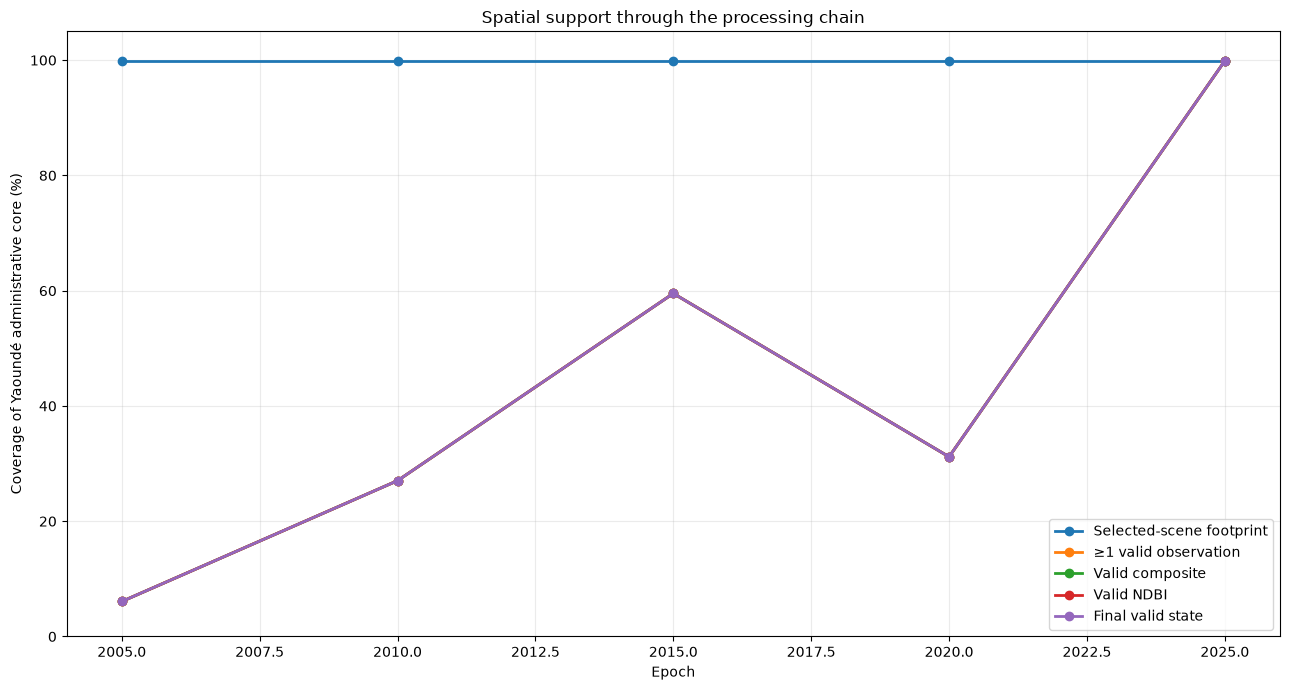

In [18]:
coverage_columns = {
    "Selected-scene footprint": "footprint_pct_of_core",
    "≥1 valid observation": "coverage_ge_1_pct_of_core",
    "Valid composite": "valid_composite_pct_of_core",
    "Valid NDBI": "valid_ndbi_pct_of_core",
    "Final valid state": "final_state_valid_pct_of_core",
}

fig, ax = plt.subplots(figsize=(13, 7))

for label, column in coverage_columns.items():
    ax.plot(
        epoch_diagnostics["epoch"],
        epoch_diagnostics[column],
        marker="o",
        linewidth=2,
        label=label,
    )

ax.set_title("Spatial support through the processing chain")
ax.set_xlabel("Epoch")
ax.set_ylabel("Coverage of Yaoundé administrative core (%)")
ax.set_ylim(0, 105)
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "02_coverage_by_processing_stage.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## 11. Observation-depth summary

Spatial coverage and observation depth are different:

- **coverage** asks whether a cell has at least one usable observation;
- **depth** asks how many usable observations support the composite at a
  covered cell.

In [19]:
observation_columns = [
    "mean_valid_observations_all_core",
    "median_valid_observations_all_core",
    "mean_valid_observations_covered",
    "median_valid_observations_covered",
]

observation_summary = epoch_diagnostics[
    ["epoch", *observation_columns]
].copy()

observation_summary

,epoch,mean_valid_observations_all_core,median_valid_observations_all_core,mean_valid_observations_covered,median_valid_observations_covered
0,2005,0.065319,0.0,1.074395,1.0
1,2010,0.270656,0.0,1.000000,1.0
2,2015,0.857950,1.0,1.439752,1.0
3,2020,0.312091,0.0,1.000000,1.0
4,2025,7.902908,7.0,7.902908,7.0


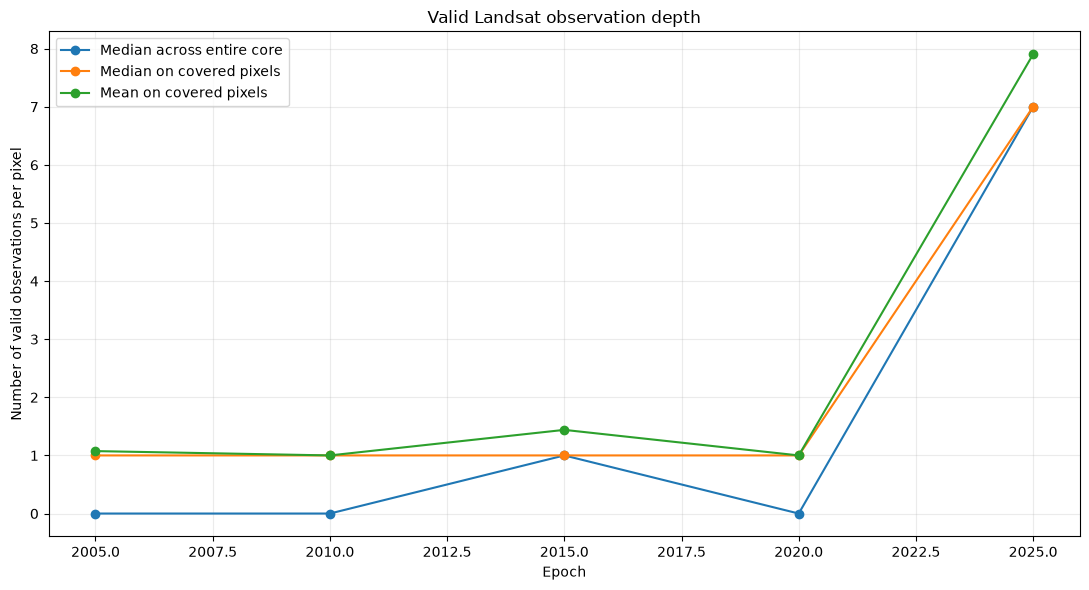

In [20]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    observation_summary["epoch"],
    observation_summary[
        "median_valid_observations_all_core"
    ],
    marker="o",
    label="Median across entire core",
)
ax.plot(
    observation_summary["epoch"],
    observation_summary[
        "median_valid_observations_covered"
    ],
    marker="o",
    label="Median on covered pixels",
)
ax.plot(
    observation_summary["epoch"],
    observation_summary[
        "mean_valid_observations_covered"
    ],
    marker="o",
    label="Mean on covered pixels",
)

ax.set_title("Valid Landsat observation depth")
ax.set_xlabel("Epoch")
ax.set_ylabel("Number of valid observations per pixel")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "03_observation_depth_by_epoch.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## 12. Valid-observation distributions: 2015 versus 2020

This comparison shows whether 2020 has:

- more zero-observation cells;
- fewer covered cells;
- lower observation depth among covered cells;
- or a combination of these conditions.

In [21]:
def histogram_frame(
    epoch: int,
    histogram: dict[int, float],
) -> pd.DataFrame:
    """Convert one Earth Engine frequency histogram to a table."""
    return pd.DataFrame(
        {
            "epoch": epoch,
            "valid_observation_count": list(histogram.keys()),
            "weighted_pixel_frequency": list(histogram.values()),
        }
    ).sort_values("valid_observation_count")


comparison_histogram = pd.concat(
    [
        histogram_frame(
            epoch,
            observation_histograms[epoch],
        )
        for epoch in [2015, 2020]
    ],
    ignore_index=True,
)

comparison_histogram.to_csv(
    REPORT_DIR / "observation_histogram_2015_2020.csv",
    index=False,
)

comparison_histogram.head()

,epoch,valid_observation_count,weighted_pixel_frequency
0,2015,0,130086.243137
1,2015,1,107472.862745
2,2015,2,84358.031373
3,2020,0,221449.619608
4,2020,1,100467.517647


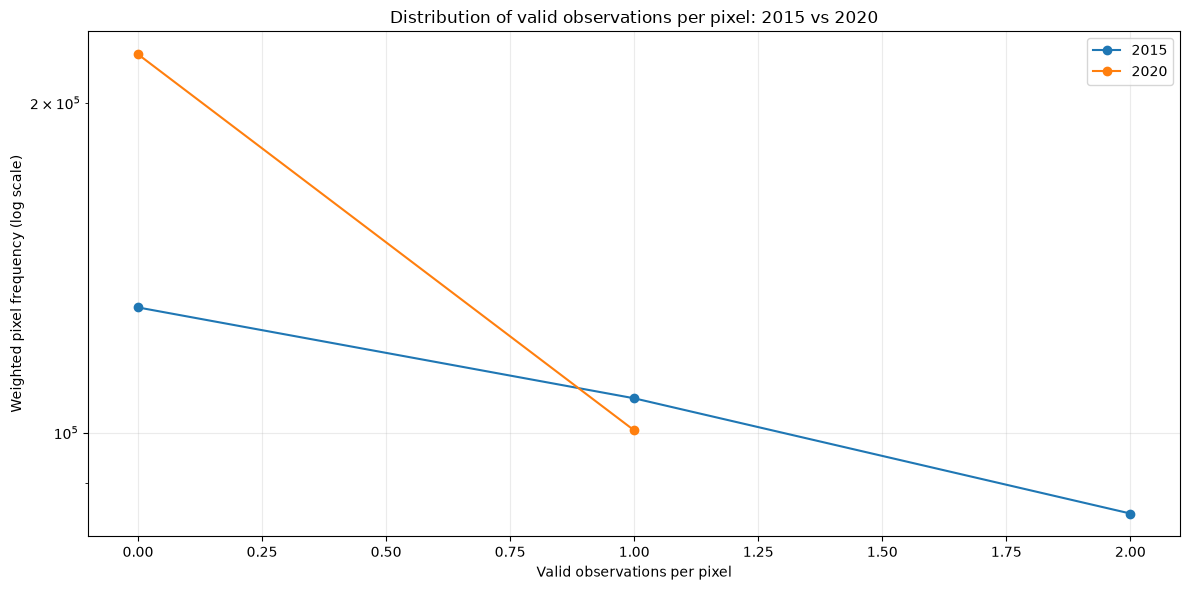

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

for epoch in [2015, 2020]:
    subset = comparison_histogram[
        comparison_histogram["epoch"] == epoch
    ]
    ax.plot(
        subset["valid_observation_count"],
        subset["weighted_pixel_frequency"],
        marker="o",
        label=str(epoch),
    )

ax.set_yscale("log")
ax.set_title(
    "Distribution of valid observations per pixel: 2015 vs 2020"
)
ax.set_xlabel("Valid observations per pixel")
ax.set_ylabel("Weighted pixel frequency (log scale)")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "04_observation_histogram_2015_2020.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## 13. Direct 2015–2020 comparison

This is the principal table to discuss with the supervisor.

In [23]:
direct_metrics = {
    "Catalogue scenes": "catalogue_scene_count",
    "Candidate scenes": "candidate_scene_count",
    "Selected scenes": "selected_scene_count",
    "Median scene cloud cover (%)": (
        "median_selected_scene_cloud_cover_pct"
    ),
    "Selected-scene footprint (%)": "footprint_pct_of_core",
    "Coverage with ≥1 observation (%)": (
        "coverage_ge_1_pct_of_core"
    ),
    "Coverage with ≥3 observations (%)": (
        "coverage_ge_3_pct_of_core"
    ),
    "Median observations across core": (
        "median_valid_observations_all_core"
    ),
    "Median observations on covered pixels": (
        "median_valid_observations_covered"
    ),
    "Valid composite coverage (%)": (
        "valid_composite_pct_of_core"
    ),
    "Valid NDBI coverage (%)": "valid_ndbi_pct_of_core",
    "Final valid-state coverage (%)": (
        "final_state_valid_pct_of_core"
    ),
}

comparison_rows = []

for label, column in direct_metrics.items():
    value_2015 = float(
        epoch_diagnostics.loc[
            epoch_diagnostics["epoch"] == 2015,
            column,
        ].iloc[0]
    )
    value_2020 = float(
        epoch_diagnostics.loc[
            epoch_diagnostics["epoch"] == 2020,
            column,
        ].iloc[0]
    )
    comparison_rows.append(
        {
            "metric": label,
            "2015": value_2015,
            "2020": value_2020,
            "2020_minus_2015": value_2020 - value_2015,
        }
    )

comparison_2015_2020 = pd.DataFrame(comparison_rows)
comparison_2015_2020.to_csv(
    REPORT_DIR / "comparison_2015_2020.csv",
    index=False,
)
comparison_2015_2020.round(2)

,metric,2015,2020,2020_minus_2015
0,Catalogue scenes,161.00,162.00,1.00
1,Candidate scenes,116.00,64.00,-52.00
2,Selected scenes,2.00,1.00,-1.00
3,Median scene cloud cover (%),56.28,69.10,12.81
4,Selected-scene footprint (%),99.89,99.89,-0.00
5,Coverage with ≥1 observation (%),59.52,31.17,-28.35
6,Coverage with ≥3 observations (%),0.00,0.00,0.00
7,Median observations across core,1.00,0.00,-1.00
8,Median observations on covered pixels,1.00,1.00,0.00
9,Valid composite coverage (%),59.52,31.17,-28.35


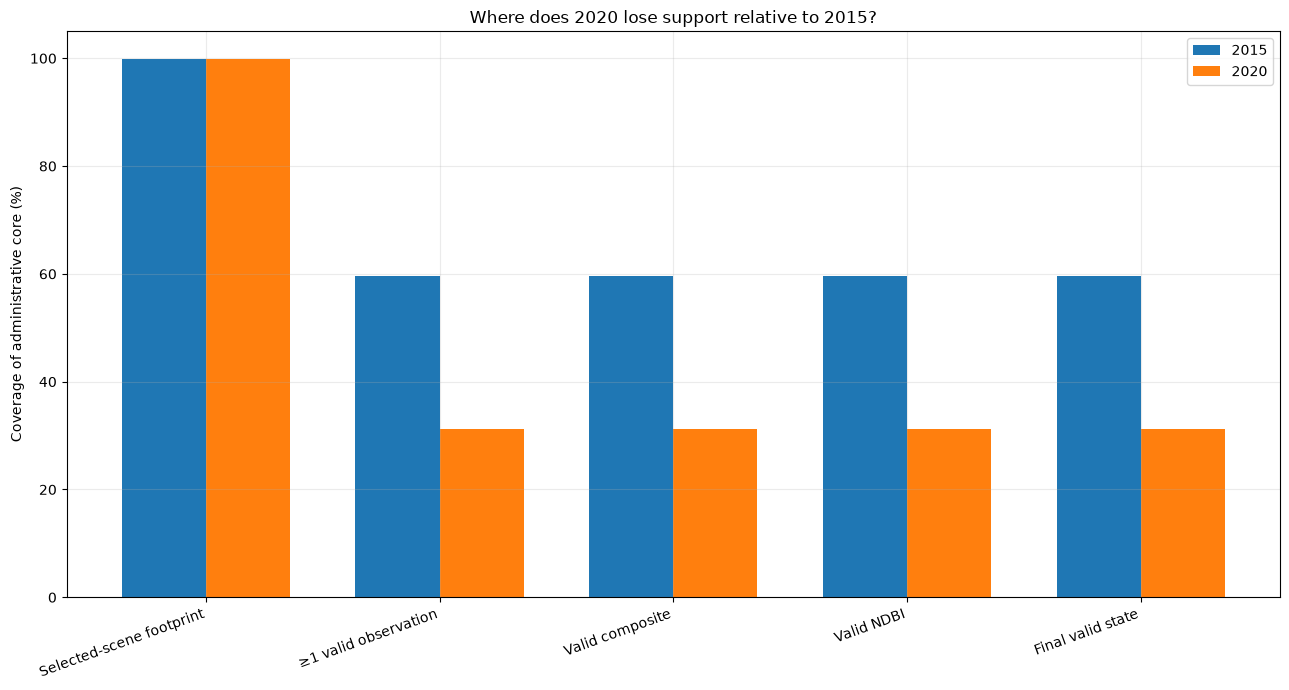

In [24]:
coverage_comparison_labels = [
    "Selected-scene footprint",
    "≥1 valid observation",
    "Valid composite",
    "Valid NDBI",
    "Final valid state",
]
coverage_comparison_columns = [
    "footprint_pct_of_core",
    "coverage_ge_1_pct_of_core",
    "valid_composite_pct_of_core",
    "valid_ndbi_pct_of_core",
    "final_state_valid_pct_of_core",
]

comparison_frame = (
    epoch_diagnostics[
        epoch_diagnostics["epoch"].isin([2015, 2020])
    ]
    .set_index("epoch")
)

x = np.arange(len(coverage_comparison_labels))
width = 0.36

fig, ax = plt.subplots(figsize=(13, 7))
ax.bar(
    x - width / 2,
    comparison_frame.loc[2015, coverage_comparison_columns],
    width,
    label="2015",
)
ax.bar(
    x + width / 2,
    comparison_frame.loc[2020, coverage_comparison_columns],
    width,
    label="2020",
)

ax.set_xticks(x)
ax.set_xticklabels(
    coverage_comparison_labels,
    rotation=20,
    ha="right",
)
ax.set_ylim(0, 105)
ax.set_ylabel("Coverage of administrative core (%)")
ax.set_title(
    "Where does 2020 lose support relative to 2015?"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "05_comparison_2015_2020.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## 14. Sensor-specific observation contribution

Some count assets contain additional bands such as:

```text
valid_count_lc08
valid_count_lc09
```

The notebook reports these bands when they exist and does not require them
for every epoch.

In [25]:
sensor_count_rows = []

for asset_row in assets.itertuples(index=False):
    image = ee.Image(asset_row.count_asset)
    band_names = image.bandNames().getInfo()
    sensor_bands = [
        band
        for band in band_names
        if str(band).startswith("valid_count_")
    ]

    for band in sensor_bands:
        sensor_image = image.select(band).unmask(0).toFloat()
        result = ee.Dictionary(
            sensor_image.reduceRegion(
                reducer=(
                    ee.Reducer.mean()
                    .combine(
                        ee.Reducer.percentile([50]),
                        sharedInputs=True,
                    )
                ),
                **REDUCTION_ARGUMENTS,
            )
        ).getInfo()

        sensor_count_rows.append(
            {
                "epoch": int(asset_row.epoch),
                "sensor_count_band": band,
                "mean_observations_all_core": float(
                    result.get(f"{band}_mean", np.nan)
                ),
                "median_observations_all_core": float(
                    result.get(f"{band}_p50", np.nan)
                ),
                "coverage_pct_of_core": mask_coverage(
                    sensor_image.gt(0)
                )["pct_of_core"],
            }
        )

sensor_contributions = pd.DataFrame(sensor_count_rows)

if sensor_contributions.empty:
    print(
        "No sensor-specific count bands are available."
    )
else:
    sensor_contributions.to_csv(
        REPORT_DIR / "sensor_observation_contributions.csv",
        index=False,
    )
    display(sensor_contributions.round(2))

,epoch,sensor_count_band,mean_observations_all_core,median_observations_all_core,coverage_pct_of_core
0,2025,valid_count_lc08,3.77,3.0,99.33
1,2025,valid_count_lc09,4.14,4.0,99.89


## 15. Spatial comparison map

The four classes are:

```text
0 = invalid in both 2015 and 2020
1 = valid only in 2015
2 = valid only in 2020
3 = valid in both
```

This map helps determine whether the lower 2020 support is spatially
concentrated or dispersed.

In [26]:
def asset_for_epoch(
    epoch: int,
    column: str,
) -> str:
    """Return one resolved asset identifier for an epoch."""
    return str(
        assets.loc[
            assets["epoch"] == epoch,
            column,
        ].iloc[0]
    )


valid_2015 = (
    ee.Image(asset_for_epoch(2015, "count_asset"))
    .select("valid_observation_count")
    .gte(1)
)
valid_2020 = (
    ee.Image(asset_for_epoch(2020, "count_asset"))
    .select("valid_observation_count")
    .gte(1)
)

comparison_classes = (
    valid_2015.toUint8()
    .add(valid_2020.toUint8().multiply(2))
    .rename("support_comparison")
)

thumbnail_url = comparison_classes.getThumbURL(
    {
        "region": core_geometry,
        "crs": grid["crs"],
        "dimensions": 1200,
        "min": 0,
        "max": 3,
        "palette": [
            "111111",
            "ef5350",
            "42a5f5",
            "66bb6a",
        ],
        "format": "png",
    }
)

print(
    "Open this temporary Earth Engine thumbnail URL "
    "to inspect the 2015–2020 support map:"
)
print(thumbnail_url)

Open this temporary Earth Engine thumbnail URL to inspect the 2015–2020 support map:
https://earthengine.googleapis.com/v1/projects/urban-sprawl-ssa/thumbnails/a027d5c993b6665e8a6ef76c13edb4b6-c9edbb52a225159efc325272a840fee5:getPixels


## 16. Internal consistency checks

The support chain should normally be non-increasing:

```text
footprint
  ≥ at least one valid observation
  ≥ valid composite
  ≥ valid NDBI
  ≥ final valid state
```

A violation larger than a small numerical tolerance may indicate that two
stages use different masks, extents, or grid conventions.

In [27]:
chain_columns = [
    "footprint_pct_of_core",
    "coverage_ge_1_pct_of_core",
    "valid_composite_pct_of_core",
    "valid_ndbi_pct_of_core",
    "final_state_valid_pct_of_core",
]
tolerance_percentage_points = 0.1

consistency_rows = []

for row in epoch_diagnostics.itertuples(index=False):
    values = [
        float(getattr(row, column))
        for column in chain_columns
    ]
    violations = [
        (
            chain_columns[index],
            chain_columns[index + 1],
            values[index],
            values[index + 1],
        )
        for index in range(len(values) - 1)
        if (
            values[index + 1]
            > values[index] + tolerance_percentage_points
        )
    ]
    consistency_rows.append(
        {
            "epoch": int(row.epoch),
            "coverage_values_between_0_and_100": all(
                -tolerance_percentage_points
                <= value
                <= 100 + tolerance_percentage_points
                for value in values
            ),
            "monotonic_support_chain": not violations,
            "violations": str(violations),
        }
    )

consistency_checks = pd.DataFrame(consistency_rows)
consistency_checks

,epoch,coverage_values_between_0_and_100,monotonic_support_chain,violations
0,2005,True,True,[]
1,2010,True,True,[]
2,2015,True,True,[]
3,2020,True,True,[]
4,2025,True,True,[]


## 17. Automatic diagnostic interpretation

The conclusion is generated from the observed stage losses. It is a
structured interpretation, not a replacement for inspecting the tables and
maps.

In [28]:
def diagnostic_statement(
    row: pd.Series,
) -> str:
    """Create a concise evidence-based interpretation for one epoch."""
    stage = str(row["dominant_loss_stage"])
    loss = float(row["dominant_loss_percentage_points"])

    explanations = {
        "core_to_scene_footprint": (
            "The largest loss occurs before QA masking because the "
            "selected-scene footprints do not cover the full core."
        ),
        "scene_footprint_to_valid_observation": (
            "The largest loss occurs between scene footprints and pixels "
            "with at least one valid observation. This points primarily "
            "to QA masking, clouds, cloud shadows, saturation, or missing "
            "usable observations inside the selected scenes."
        ),
        "valid_observation_to_composite": (
            "The largest loss occurs when valid observations are converted "
            "into the final median composite. The composite construction "
            "and its output mask should be inspected."
        ),
        "composite_to_ndbi": (
            "The largest loss occurs when NDBI validity is applied. "
            "Index denominators, finite-value masks, and Day 4 validity "
            "logic should be inspected."
        ),
        "ndbi_to_final_state": (
            "The largest loss occurs between valid NDBI and the final "
            "built-state validity mask. The final-state construction "
            "should be inspected."
        ),
    }

    return (
        f"For {int(row['epoch'])}, the dominant support loss is "
        f"`{stage}` ({loss:.2f} percentage points). "
        + explanations.get(
            stage,
            "The dominant stage could not be classified.",
        )
    )


interpretation_lines = [
    diagnostic_statement(row)
    for _, row in epoch_diagnostics.iterrows()
]

for line in interpretation_lines:
    print(line)

For 2005, the dominant support loss is `scene_footprint_to_valid_observation` (93.81 percentage points). The largest loss occurs between scene footprints and pixels with at least one valid observation. This points primarily to QA masking, clouds, cloud shadows, saturation, or missing usable observations inside the selected scenes.
For 2010, the dominant support loss is `scene_footprint_to_valid_observation` (72.85 percentage points). The largest loss occurs between scene footprints and pixels with at least one valid observation. This points primarily to QA masking, clouds, cloud shadows, saturation, or missing usable observations inside the selected scenes.
For 2015, the dominant support loss is `scene_footprint_to_valid_observation` (40.37 percentage points). The largest loss occurs between scene footprints and pixels with at least one valid observation. This points primarily to QA masking, clouds, cloud shadows, saturation, or missing usable observations inside the selected scenes.
F

In [29]:
row_2015 = epoch_diagnostics[
    epoch_diagnostics["epoch"] == 2015
].iloc[0]
row_2020 = epoch_diagnostics[
    epoch_diagnostics["epoch"] == 2020
].iloc[0]

support_difference = (
    float(row_2020["final_state_valid_pct_of_core"])
    - float(row_2015["final_state_valid_pct_of_core"])
)
footprint_difference = (
    float(row_2020["footprint_pct_of_core"])
    - float(row_2015["footprint_pct_of_core"])
)
valid_observation_difference = (
    float(row_2020["coverage_ge_1_pct_of_core"])
    - float(row_2015["coverage_ge_1_pct_of_core"])
)

if abs(footprint_difference) >= abs(
    valid_observation_difference
) * 0.75:
    comparison_conclusion = (
        "The 2015–2020 difference begins substantially at the "
        "selected-scene footprint stage."
    )
elif valid_observation_difference < -5:
    comparison_conclusion = (
        "The 2020 scenes cover more area than the final usable support. "
        "The main 2015–2020 difference appears after QA masking, because "
        "2020 has fewer pixels with at least one valid observation."
    )
else:
    comparison_conclusion = (
        "The 2015–2020 difference is not explained by one large loss "
        "before the composite stage. Inspect the detailed stage table."
    )

print(
    f"Final valid-state difference, 2020 minus 2015: "
    f"{support_difference:.2f} percentage points."
)
print(comparison_conclusion)

Final valid-state difference, 2020 minus 2015: -28.35 percentage points.
The 2020 scenes cover more area than the final usable support. The main 2015–2020 difference appears after QA masking, because 2020 has fewer pixels with at least one valid observation.


## 18. Generate the supervisor-ready diagnostic report

The report records the existing compositing rule and the observed cause of
support loss. It does not recommend reprocessing unless the evidence later
supports a predefined reproducible fallback rule.

In [32]:
report_lines = [
    "# Landsat Spatial-Support Diagnostic",
    "",
    "## Objective",
    "",
    (
        "Determine why valid spatial support is lower in 2020 than "
        "in 2015 without changing the frozen compositing protocol."
    ),
    "",
    "## Definition",
    "",
    (
        "Valid spatial support is the area within the Yaoundé "
        "administrative core where the final Landsat composite "
        "contains usable pixels after QA masking and where NDBI can "
        "be calculated."
    ),
    "",
    "## Compositing protocol",
    "",
    protocol_table.to_markdown(index=False),
    "",
    "## Scene inventory",
    "",
    scene_inventory.to_markdown(index=False),
    "",
    "## Support by processing stage",
    "",
    epoch_diagnostics[display_columns].round(2).to_markdown(
        index=False
    ),
    "",
    "## Direct comparison: 2015 versus 2020",
    "",
    comparison_2015_2020.round(2).to_markdown(index=False),
    "",
    "## Diagnostic interpretation",
    "",
]

report_lines.extend(
    f"- {line}"
    for line in interpretation_lines
)

report_lines.extend(
    [
        "",
        "## 2015–2020 conclusion",
        "",
        comparison_conclusion,
        "",
        (
            f"The final valid-state difference is "
            f"{support_difference:.2f} percentage points "
            f"(2020 minus 2015)."
        ),
        "",
        "## Methodological decision",
        "",
        (
            "The current temporal-window decision rule remains "
            "unchanged. No epoch has been manually reprocessed as part "
            "of this diagnostic."
        ),
        "",
        "## Generated figures",
        "",
    ]
)

for figure_path in sorted(FIGURE_DIR.glob("*.png")):
    relative_path = figure_path.relative_to(REPORT_DIR)
    title = figure_path.stem.replace("_", " ").title()
    report_lines.extend(
        [
            f"### {title}",
            "",
            f"![{title}]({relative_path.as_posix()})",
            "",
        ]
    )

report_path = REPORT_DIR / "support_diagnostic_report.md"
report_path.write_text(
    "\n".join(report_lines) + "\n",
    encoding="utf-8",
)

print(f"Diagnostic table: {output_csv}")
print(f"Diagnostic report: {report_path}")
print(f"Figures: {FIGURE_DIR}")

Diagnostic table: /Users/omer/Documents/MIORPA/Pending.../SprawlGP/reports/support_diagnostics/epoch_support_diagnostics.csv
Diagnostic report: /Users/omer/Documents/MIORPA/Pending.../SprawlGP/reports/support_diagnostics/support_diagnostic_report.md
Figures: /Users/omer/Documents/MIORPA/Pending.../SprawlGP/reports/support_diagnostics/figures


## 19. Recommended interpretation sequence

Review the outputs in this order:

1. `01_scene_inventory.png`
2. `02_coverage_by_processing_stage.png`
3. `03_observation_depth_by_epoch.png`
4. `04_observation_histogram_2015_2020.png`
5. `05_comparison_2015_2020.png`
6. the spatial comparison thumbnail;
7. `support_diagnostic_report.md`

The key decision is not whether 2020 looks unusual. It is **where in the
frozen processing chain its support is lost**.

In [31]:
!python -m pip install tabulate


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip
